##Jai Ganesha

# 02 — Baseline Evaluation

Sections:
  A) YOLO-World pretrained baseline on VisDrone val
  B) SAM-2 prompted segmentation on COCO val
  C) Unified detect → segment → visualize pipeline

Inputs:
  - processed/visdrone/images/val/ + labels/val/
  - processed/visdrone/stress_set.json
  - raw/COCO/val2017/ + processed/coco/labels/val/
  - checkpoints/yoloworld/yolov8l-world.pt
  - checkpoints/sam2/sam2.1_hiera_large.pt

Outputs (all under outputs/):
  - metrics/yoloworld_baseline.json
  - metrics/yoloworld_per_class.csv
  - metrics/sam2_baseline.json
  - metrics/sam2_instance_results.csv
  - visualizations/baseline_detections/
  - visualizations/baseline_sam2/
  - visualizations/unified_pipeline/

Run 0_setup.ipynb before this notebook every session.

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 0a: Install all packages
# Run this cell fully and wait for it to complete before
# running Cell 0b. Do NOT combine with Cell 0b.
# In Colab, pip installs are only visible to the NEXT cell,
# not within the same cell where they ran.
# ─────────────────────────────────────────────────────────────
import subprocess, sys

def install(pkg, label=None):
    label = label or pkg
    print(f"  Installing {label}...", end=" ", flush=True)
    r = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True, text=True
    )
    print("✅" if r.returncode == 0 else f"❌\n{r.stderr[-300:]}")

print("Installing packages...")
install("ultralytics==8.3.145",   "ultralytics (pinned 8.3.145)")
install("supervision",            "supervision")
install("albumentations",         "albumentations")
install("pycocotools",            "pycocotools")
install("einops",                 "einops")
install("opencv-python-headless", "opencv-headless")
install("hydra-core",             "hydra-core")       # sam2/__init__.py needs this
install("iopath",                 "iopath")
install("submitit",               "submitit")
install("git+https://github.com/ultralytics/CLIP.git", "CLIP")

print("\n✅ All packages installed.")
print("   → Now run Cell 0b to set up repos and verify imports.")

Installing packages...
  Installing ultralytics (pinned 8.3.145)... ✅
  Installing supervision... ✅
  Installing albumentations... ✅
  Installing pycocotools... ✅
  Installing einops... ✅
  Installing opencv-headless... ✅
  Installing hydra-core... ✅
  Installing iopath... ✅
  Installing submitit... ✅
  Installing CLIP... ✅

✅ All packages installed.
   → Now run Cell 0b to set up repos and verify imports.


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 0b: Clone repos, set sys.path, verify all imports
# Run this AFTER Cell 0a has fully completed.
# hydra-core installed in 0a is now visible to this cell.
# ─────────────────────────────────────────────────────────────
import subprocess, sys, os, importlib

# Force Python to rescan site-packages for newly installed packages
importlib.invalidate_caches()

# ── Clear any stale module cache from this session ────────────
for mod in list(sys.modules.keys()):
    if mod == "sam2" or mod.startswith("sam2.") \
    or mod == "ultralytics" or mod.startswith("ultralytics.") \
    or mod == "hydra" or mod.startswith("hydra."):
        del sys.modules[mod]

# ── Mount Drive and load config ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import json
CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

YOLOWORLD_REPO = cfg["yoloworld_repo"]   # /content/YOLO-World
SAM2_REPO      = cfg["sam2_repo"]        # /content/sam2

# ── Clone repos if missing (wiped on every session reset) ─────
def clone_if_missing(repo_path, url, name):
    if not os.path.exists(repo_path):
        print(f"  Cloning {name}...", end=" ", flush=True)
        r = subprocess.run(f"git clone -q {url} {repo_path}",
                           shell=True, capture_output=True, text=True)
        print("✅" if r.returncode == 0 else f"❌ {r.stderr[-100:]}")
    else:
        print(f"  {name} already present ✅")

clone_if_missing(YOLOWORLD_REPO,
                 "https://github.com/AILab-CVC/YOLO-World.git",
                 "YOLO-World")
clone_if_missing(SAM2_REPO,
                 "https://github.com/facebookresearch/sam2.git",
                 "SAM-2")

# ── Add ONLY SAM-2 repo root to sys.path ─────────────────────
# YOLO-World is intentionally NOT added — its internal ultralytics/
# subfolder would shadow the pip-installed package.
if SAM2_REPO not in sys.path:
    sys.path.insert(0, SAM2_REPO)

# ── Verify imports ────────────────────────────────────────────
print("\nVerifying imports...")
import torch
print(f"  torch      : {torch.__version__} | CUDA: {torch.cuda.is_available()}")

try:
    import ultralytics
    from ultralytics import YOLO
    print(f"  ultralytics: {ultralytics.__version__} ✅")
except Exception as e:
    print(f"  ultralytics: ❌ {e}")

try:
    import hydra
    print(f"  hydra-core : {hydra.__version__} ✅")
except Exception as e:
    print(f"  hydra-core : ❌ {e}  ← if this fails, re-run Cell 0a")

try:
    from sam2.build_sam import build_sam2
    from sam2.sam2_image_predictor import SAM2ImagePredictor
    from sam2.sam2_video_predictor import SAM2VideoPredictor
    print(f"  SAM-2      : ✅")
except Exception as e:
    print(f"  SAM-2      : ❌ {e}")

try:
    import cv2
    print(f"  opencv     : {cv2.__version__} ✅")
except Exception as e:
    print(f"  opencv     : ❌ {e}")

try:
    from pycocotools import mask as cocomask
    print(f"  pycocotools: ✅")
except Exception as e:
    print(f"  pycocotools: ❌ {e}")

print("\n✅ Cell 0b complete. Run Cell 1 next.")

Mounted at /content/drive
  Cloning YOLO-World... ✅
  Cloning SAM-2... ✅

Verifying imports...
  torch      : 2.10.0+cu128 | CUDA: True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  ultralytics: 8.3.145 ✅
  hydra-core : 1.3.2 ✅
  SAM-2      : ✅
  opencv     : 4.13.0 ✅
  pycocotools: ✅

✅ Cell 0b complete. Run Cell 1 next.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Imports, config, all path variables, staging dirs
# ─────────────────────────────────────────────────────────────
import json, os, sys, shutil, subprocess, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from pycocotools import mask as cocomask

CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

# ── Unpack all paths from config ──────────────────────────────
PROC_VISDRONE  = cfg["proc_visdrone"]
RAW_COCO       = cfg["raw_coco"]
PROC_COCO      = cfg["proc_coco"]
OUTPUT_DIR     = cfg["output_dir"]
VIZ_DIR        = cfg["viz_dir"]
METRICS_DIR    = cfg["metrics_dir"]
YW_CKPT_PATH   = cfg["yw_ckpt_path"]
SAM2_CKPT_PATH = cfg["sam2_ckpt_path"]
SAM2_REPO      = cfg["sam2_repo"]
DEVICE         = cfg.get("device", "cuda")

VD_VAL_IMG  = os.path.join(PROC_VISDRONE, "images", "val")
VD_VAL_LBL  = os.path.join(PROC_VISDRONE, "labels", "val")
STRESS_JSON = os.path.join(PROC_VISDRONE, "stress_set.json")
COCO_VAL_IMG = os.path.join(RAW_COCO, "val2017")
COCO_VAL_LBL = os.path.join(PROC_COCO, "labels", "val")

# ── Class definitions ─────────────────────────────────────────
YOLO_CLASSES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor", "others"
]
COCO_CLASSES     = ["person", "bicycle", "car", "motorcycle", "bus", "truck"]
COCO_CAT_TO_YOLO = {1: 0, 2: 1, 3: 2, 4: 3, 6: 4, 8: 5}

# ── Local staging — mirrors outputs/ structure exactly ────────
# tar -C STAGE . extracted into OUTPUT_DIR gives:
#   OUTPUT_DIR/metrics/...           ✅  (no double subfolder)
#   OUTPUT_DIR/visualizations/...   ✅
STAGE          = "/content/staging/baselines"
STAGE_METRICS  = f"{STAGE}/metrics"
STAGE_VIZ_DET  = f"{STAGE}/visualizations/baseline_detections"
STAGE_VIZ_SAM2 = f"{STAGE}/visualizations/baseline_sam2"
STAGE_VIZ_PIPE = f"{STAGE}/visualizations/unified_pipeline"

for d in [STAGE_METRICS, STAGE_VIZ_DET, STAGE_VIZ_SAM2, STAGE_VIZ_PIPE]:
    os.makedirs(d, exist_ok=True)

# ── Helper: copy file to Drive dir with OS-level sync ─────────
def cp_sync(src, dst_dir):
    r = subprocess.run(f"cp '{src}' '{dst_dir}/' && sync",
                       shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise IOError(f"cp failed: {r.stderr}")
    dst = os.path.join(dst_dir, os.path.basename(src))
    return dst, os.path.getsize(dst)

# ── Verify all inputs exist ───────────────────────────────────
print("Verifying inputs...")
all_ok = True
for name, path in [
    ("VD val images",   VD_VAL_IMG),
    ("VD val labels",   VD_VAL_LBL),
    ("stress_set.json", STRESS_JSON),
    ("COCO val images", COCO_VAL_IMG),
    ("COCO val labels", COCO_VAL_LBL),
    ("YOLO-World ckpt", YW_CKPT_PATH),
    ("SAM-2 ckpt",      SAM2_CKPT_PATH),
]:
    exists = os.path.exists(path)
    print(f"  {'✅' if exists else '❌ MISSING'}  {name}")
    if not exists:
        all_ok = False

if all_ok:
    print(f"\n✅ Cell 1 complete. Device: {DEVICE}")
else:
    print("\n❌ Fix missing inputs before continuing.")

Verifying inputs...
  ✅  VD val images
  ✅  VD val labels
  ✅  stress_set.json
  ✅  COCO val images
  ✅  COCO val labels
  ✅  YOLO-World ckpt
  ✅  SAM-2 ckpt

✅ Cell 1 complete. Device: cuda


## Section A — YOLO-World Pretrained Baseline on VisDrone Val

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 2: Load YOLO-World pretrained model
# ─────────────────────────────────────────────────────────────
import torch
from ultralytics import YOLO

print("Loading YOLO-World...")
yw_model = YOLO(YW_CKPT_PATH)
yw_model.set_classes(YOLO_CLASSES)

# Quick forward pass to confirm model works
dummy = np.zeros((64, 64, 3), dtype=np.uint8)
_ = yw_model.predict(dummy, verbose=False)
del dummy

print(f"✅ YOLO-World loaded")
#print(f"✅ yw_mode ", yw_model)
print(f"   Checkpoint : {YW_CKPT_PATH}")
print(f"   Classes    : {YOLO_CLASSES}")
if torch.cuda.is_available():
    print(f"   VRAM used  : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading YOLO-World...
✅ YOLO-World loaded
   Checkpoint : /content/drive/MyDrive/DLCV_OV_Analytics/checkpoints/yoloworld/yolov8l-world.pt
   Classes    : ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor', 'others']
   VRAM used  : 1.92 GB


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3: Run YOLO-World evaluation on VisDrone val + stress set
# ─────────────────────────────────────────────────────────────

def load_gt_boxes(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                boxes.append((int(parts[0]), *map(float, parts[1:])))
    return boxes

def yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h):
    return ((xc-bw/2)*img_w, (yc-bh/2)*img_h,
            (xc+bw/2)*img_w, (yc+bh/2)*img_h)

def compute_iou(a, b):
    xi1, yi1 = max(a[0],b[0]), max(a[1],b[1])
    xi2, yi2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    if inter == 0:
        return 0.0
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)

def compute_ap(prec_list, rec_list):
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        p = [p for p, r in zip(prec_list, rec_list) if r >= t]
        ap += max(p) if p else 0.0
    return ap / 11.0

def evaluate_detections(img_dir, lbl_dir, model, classes,
                         iou_thresh=0.5, conf_thresh=0.25, desc="eval"):
    """Compute per-class AP@0.5 and mAP@0.5 over all images in img_dir."""
    img_files = sorted(f for f in os.listdir(img_dir) if f.endswith(".jpg"))
    class_data = {i: {"scores": [], "tp_flags": [], "n_gt": 0}
                  for i in range(len(classes))}

    for img_file in tqdm(img_files, desc=desc):
        img = cv2.imread(os.path.join(img_dir, img_file))
        if img is None:
            continue
        img_h, img_w = img.shape[:2]
        lbl_path = os.path.join(lbl_dir, Path(img_file).stem + ".txt")

        # Ground truth grouped by class
        gt_by_cls = defaultdict(list)
        for cls_id, xc, yc, bw, bh in load_gt_boxes(lbl_path):
            gt_by_cls[cls_id].append(
                {"box": yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h), "used": False}
            )
        for cls_id in range(len(classes)):
            class_data[cls_id]["n_gt"] += len(gt_by_cls[cls_id])

        # Predictions
        results = model.predict(
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB), verbose=False, conf=conf_thresh
        )
        pred_by_cls = defaultdict(list)
        if results and results[0].boxes is not None:
            for box in results[0].boxes:
                pred_by_cls[int(box.cls.item())].append({
                    "box" : box.xyxy[0].tolist(),
                    "conf": float(box.conf.item()),
                })

        # Match preds to GT (greedy, descending confidence)
        for cls_id in range(len(classes)):
            preds = sorted(pred_by_cls[cls_id], key=lambda x: -x["conf"])
            gts   = gt_by_cls[cls_id]
            for pred in preds:
                best_iou, best_j = iou_thresh, -1
                for j, gt in enumerate(gts):
                    if gt["used"]:
                        continue
                    iou = compute_iou(pred["box"], gt["box"])
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                is_tp = best_j >= 0
                if is_tp:
                    gts[best_j]["used"] = True
                class_data[cls_id]["scores"].append(pred["conf"])
                class_data[cls_id]["tp_flags"].append(is_tp)

    # Compute per-class AP
    per_class_ap = {}
    for cls_id, d in class_data.items():
        pairs = sorted(zip(d["scores"], d["tp_flags"]), key=lambda x: -x[0])
        tp_c, fp_c, precs, recs = 0, 0, [], []
        n_gt = d["n_gt"]
        for conf, is_tp in pairs:
            if is_tp: tp_c += 1
            else:     fp_c += 1
            precs.append(tp_c / (tp_c + fp_c))
            recs.append(tp_c / n_gt if n_gt > 0 else 0)
        ap = compute_ap(precs, recs) if precs else 0.0
        per_class_ap[classes[cls_id]] = round(ap, 4)

    return round(float(np.mean(list(per_class_ap.values()))), 4), per_class_ap


# ── Full val split ─────────────────────────────────────────────
print("=" * 55)
print("  Section A — YOLO-World Baseline: VisDrone Val")
print("=" * 55)
t0 = time.time()
map50_full, ap_full = evaluate_detections(
    VD_VAL_IMG, VD_VAL_LBL, yw_model, YOLO_CLASSES, desc="val"
)
print(f"\n  mAP@0.5 (full val) : {map50_full:.4f}  [{time.time()-t0:.0f}s]")
print(f"\n  Per-class AP@0.5:")
for cls, ap in ap_full.items():
    print(f"    {cls:<20} {ap:.4f}  {'█'*int(ap*30)}")

# ── Stress set (copy to local SSD — faster than symlinking Drive paths) ──
print(f"\n{'='*55}")
print("  Stress Set Evaluation (200 hardest images)")
print("="*55)
with open(STRESS_JSON) as f:
    stress_items = json.load(f)

STRESS_IMG_LOCAL = "/content/staging/stress_imgs"
STRESS_LBL_LOCAL = "/content/staging/stress_lbls"
os.makedirs(STRESS_IMG_LOCAL, exist_ok=True)
os.makedirs(STRESS_LBL_LOCAL, exist_ok=True)

# Copy (not symlink) stress images to local SSD for fast inference
copied = 0
for item in stress_items:
    if copied >= 200:
        break
    img_src = item["image_path"]
    lbl_src = item["label_path"]
    if not os.path.exists(img_src):
        continue
    dst_img = os.path.join(STRESS_IMG_LOCAL, os.path.basename(img_src))
    dst_lbl = os.path.join(STRESS_LBL_LOCAL, Path(img_src).stem + ".txt")
    if not os.path.exists(dst_img):
        shutil.copy2(img_src, dst_img)
    if os.path.exists(lbl_src) and not os.path.exists(dst_lbl):
        shutil.copy2(lbl_src, dst_lbl)
    copied += 1

print(f"  Copied {copied} stress images to local SSD.")
t0 = time.time()
map50_stress, ap_stress = evaluate_detections(
    STRESS_IMG_LOCAL, STRESS_LBL_LOCAL, yw_model, YOLO_CLASSES, desc="stress"
)
print(f"\n  mAP@0.5 (stress)   : {map50_stress:.4f}  [{time.time()-t0:.0f}s]")
print(f"\n  Per-class AP@0.5 (stress):")
for cls, ap in ap_stress.items():
    print(f"    {cls:<20} {ap:.4f}  {'█'*int(ap*30)}")

  Section A — YOLO-World Baseline: VisDrone Val


val: 100%|██████████| 548/548 [02:39<00:00,  3.43it/s]



  mAP@0.5 (full val) : 0.1036  [160s]

  Per-class AP@0.5:
    pedestrian           0.0909  ██
    people               0.0000  
    bicycle              0.0909  ██
    car                  0.3397  ██████████
    van                  0.1408  ████
    truck                0.1343  ████
    tricycle             0.0909  ██
    awning-tricycle      0.0350  █
    bus                  0.2170  ██████
    motor                0.0000  
    others               0.0000  

  Stress Set Evaluation (200 hardest images)
  Copied 200 stress images to local SSD.


stress: 100%|██████████| 200/200 [00:05<00:00, 35.75it/s]


  mAP@0.5 (stress)   : 0.0882  [6s]

  Per-class AP@0.5 (stress):
    pedestrian           0.0422  █
    people               0.0000  
    bicycle              0.0909  ██
    car                  0.3436  ██████████
    van                  0.1455  ████
    truck                0.1462  ████
    tricycle             0.0364  █
    awning-tricycle      0.0303  
    bus                  0.1350  ████
    motor                0.0000  
    others               0.0000  


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 4: Save YOLO-World metrics and visualizations to staging
# ─────────────────────────────────────────────────────────────

# ── Metrics JSON ──────────────────────────────────────────────
yw_metrics = {
    "model"             : "YOLO-World pretrained (yolov8l-world.pt)",
    "dataset"           : "VisDrone val",
    "classes"           : YOLO_CLASSES,
    "map50_full_val"    : map50_full,
    "map50_stress_set"  : map50_stress,
    "per_class_ap_full" : ap_full,
    "per_class_ap_stress": ap_stress,
}
with open(f"{STAGE_METRICS}/yoloworld_baseline.json", "w") as f:
    json.dump(yw_metrics, f, indent=2)

# ── Per-class CSV ──────────────────────────────────────────────
rows = [{"class": c,
         "ap_full_val": ap_full.get(c, 0),
         "ap_stress":   ap_stress.get(c, 0)}
        for c in YOLO_CLASSES]
pd.DataFrame(rows).to_csv(f"{STAGE_METRICS}/yoloworld_per_class.csv", index=False)
print("✅ YOLO-World metrics saved to staging.")

# ── Bar chart: full val vs stress set per-class AP ────────────
fig, ax = plt.subplots(figsize=(14, 5))
x   = np.arange(len(YOLO_CLASSES))
w   = 0.35
apf = [ap_full.get(c, 0)   for c in YOLO_CLASSES]
aps = [ap_stress.get(c, 0) for c in YOLO_CLASSES]
ax.bar(x - w/2, apf, w, label=f"Full val  (mAP={map50_full:.3f})",   color="#3B8BD4")
ax.bar(x + w/2, aps, w, label=f"Stress set (mAP={map50_stress:.3f})", color="#E05C5C")
ax.set_xticks(x)
ax.set_xticklabels(YOLO_CLASSES, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("AP@0.5")
ax.set_ylim(0, 1)
ax.set_title("YOLO-World Pretrained — Per-Class AP: Full Val vs Stress Set")
ax.legend()
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ_DET}/yoloworld_baseline_ap.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Sample detection grid (6 val images from local SSD) ───────
COLOR_MAP = {
    0:(255,80,80),  1:(255,160,80), 2:(80,180,80),   3:(80,120,255),
    4:(180,80,255), 5:(255,220,60), 6:(80,220,220),   7:(200,120,80),
    8:(255,100,180),9:(100,200,100),10:(180,180,180),
}
sample_imgs = sorted(os.listdir(STRESS_IMG_LOCAL))[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, img_file in enumerate(sample_imgs):
    img = cv2.imread(os.path.join(STRESS_IMG_LOCAL, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = yw_model.predict(img, verbose=False, conf=0.25)
    n = 0
    if results and results[0].boxes is not None:
        for box in results[0].boxes:
            cls_id = int(box.cls.item())
            x1,y1,x2,y2 = [int(v) for v in box.xyxy[0].tolist()]
            color = COLOR_MAP.get(cls_id, (200,200,200))
            cv2.rectangle(img, (x1,y1), (x2,y2), color, 1)
            cv2.putText(img, f"{YOLO_CLASSES[cls_id]} {float(box.conf.item()):.2f}",
                        (x1, max(0,y1-3)), cv2.FONT_HERSHEY_SIMPLEX, 0.3, color, 1)
            n += 1
    axes[i].imshow(img)
    axes[i].set_title(f"{img_file}\n{n} detections", fontsize=8)
    axes[i].axis("off")
plt.suptitle("YOLO-World Pretrained — Sample Detections (Stress Set)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ_DET}/yoloworld_sample_detections.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Section A charts saved to staging.")

Output hidden; open in https://colab.research.google.com to view.

## Section B — SAM-2 Prompted Segmentation on COCO Val

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 5: Load SAM-2, run box-prompted segmentation on COCO val
# ─────────────────────────────────────────────────────────────
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# ── Free YOLO-World VRAM if loaded ───────────────────────────
if 'yw_model' in dir():
    del yw_model
    torch.cuda.empty_cache()
    print("✅ YOLO-World unloaded from VRAM.")
else:
    torch.cuda.empty_cache()
    print("ℹ️  yw_model not in memory — VRAM cleared anyway.")

# ── Load SAM-2 using ABSOLUTE config path ─────────────────────
# FIX: build_sam2 needs absolute path — relative path fails unless
# CWD happens to be SAM2_REPO, which it isn't in Colab
sam2_cfg   = "configs/sam2.1/sam2.1_hiera_l.yaml"
print(f"Loading SAM-2 with config: {sam2_cfg}")
sam2_model = build_sam2(sam2_cfg, SAM2_CKPT_PATH, device=DEVICE)
predictor  = SAM2ImagePredictor(sam2_model)
print(f"✅ SAM-2 loaded on {DEVICE}")
if torch.cuda.is_available():
    print(f"   VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Load COCO val annotations ─────────────────────────────────
print("\nLoading COCO val annotations...")
with open(os.path.join(RAW_COCO, "annotations", "instances_val2017.json")) as f:
    coco_data = json.load(f)

img_info = {img["id"]: img for img in coco_data["images"]}

anns_by_img = defaultdict(list)
for ann in coco_data["annotations"]:
    if ann["category_id"] in COCO_CAT_TO_YOLO:
        anns_by_img[ann["image_id"]].append(ann)
del coco_data

# Images that have both label files and GT masks
val_lbl_stems = {Path(f).stem for f in os.listdir(COCO_VAL_LBL) if f.endswith(".txt")}
eligible_ids  = [
    img_id for img_id, info in img_info.items()
    if Path(info["file_name"]).stem in val_lbl_stems
    and len(anns_by_img[img_id]) > 0
]
print(f"Eligible images: {len(eligible_ids):,}")

# ── Mask decode helper ────────────────────────────────────────
def decode_mask(seg, img_h, img_w):
    if isinstance(seg, list):
        rle = cocomask.frPyObjects(seg, img_h, img_w)
        rle = cocomask.merge(rle)
    elif isinstance(seg, dict):
        rle = seg
        if isinstance(rle.get("counts"), list):
            rle = cocomask.frPyObjects(rle, img_h, img_w)
    else:
        return None
    return cocomask.decode(rle).astype(bool)

# ── Run SAM-2 on 100 sample images ───────────────────────────
EVAL_SAMPLE = 100
sample_ids  = eligible_ids[:EVAL_SAMPLE]
sam2_results = []

print(f"\nRunning SAM-2 on {len(sample_ids)} COCO val images...")
for img_id in tqdm(sample_ids, desc="SAM-2 eval"):
    info     = img_info[img_id]
    img_path = os.path.join(COCO_VAL_IMG, info["file_name"])
    if not os.path.exists(img_path):
        continue
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_h, img_w = img_rgb.shape[:2]

    predictor.set_image(img_rgb)

    for ann in anns_by_img[img_id]:
        seg    = ann.get("segmentation")
        if not seg:
            continue
        x, y, w, h = ann["bbox"]
        x1 = max(0.0, x)
        y1 = max(0.0, y)
        x2 = min(float(img_w), x + w)
        y2 = min(float(img_h), y + h)
        if x2 <= x1 or y2 <= y1:
            continue

        try:
            masks, scores, _ = predictor.predict(
                box=np.array([[x1, y1, x2, y2]], dtype=np.float32),
                multimask_output=False
            )
        except Exception:
            continue

        if masks is None or len(masks) == 0:
            continue

        gt_mask   = decode_mask(seg, img_h, img_w)
        if gt_mask is None:
            continue
        # Squeeze extra dim: SAM-2 returns (1, 1, H, W) for single box
        pred_mask = masks[0].squeeze().astype(bool)
        inter = (pred_mask & gt_mask).sum()
        union = (pred_mask | gt_mask).sum()
        iou   = float(inter) / float(union) if union > 0 else 0.0

        sam2_results.append({
            "image_id"   : img_id,
            "category_id": ann["category_id"],
            "class_name" : COCO_CLASSES[COCO_CAT_TO_YOLO[ann["category_id"]]],
            "pred_score" : float(scores[0]),
            "mask_iou"   : round(iou, 4),
        })

print(f"\n✅ SAM-2 evaluation complete. {len(sam2_results):,} instances evaluated.")

✅ YOLO-World unloaded from VRAM.
Loading SAM-2 with config: configs/sam2.1/sam2.1_hiera_l.yaml
✅ SAM-2 loaded on cuda
   VRAM used: 3.00 GB

Loading COCO val annotations...
Eligible images: 2,968

Running SAM-2 on 100 COCO val images...


SAM-2 eval: 100%|██████████| 100/100 [00:21<00:00,  4.55it/s]


✅ SAM-2 evaluation complete. 511 instances evaluated.


  SAM-2 Baseline — Box-Prompted Mask IoU

  Mean mask IoU: 0.8085

  Per-class mean IoU:
    bus          0.8674  ██████████████████████████
    car          0.8507  █████████████████████████
    truck        0.8432  █████████████████████████
    person       0.8061  ████████████████████████
    motorcycle   0.7177  █████████████████████
    bicycle      0.5988  █████████████████

✅ SAM-2 metrics saved to staging.


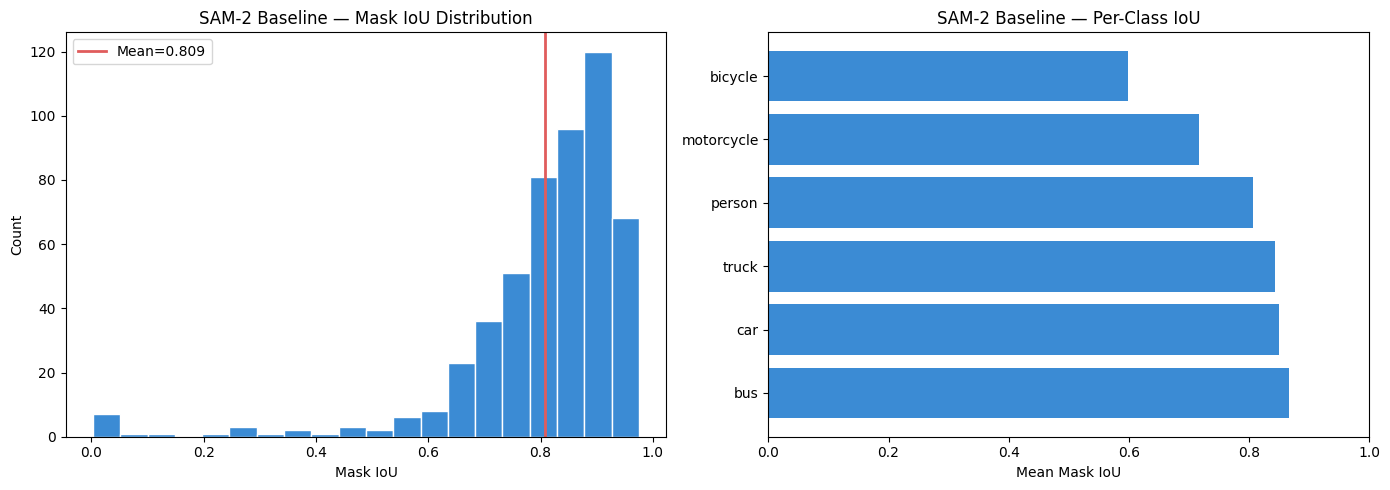

✅ SAM-2 charts saved to staging.


In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 6: Save SAM-2 metrics and visualizations to staging
# ─────────────────────────────────────────────────────────────
df_sam2    = pd.DataFrame(sam2_results)
mean_iou   = float(df_sam2["mask_iou"].mean())
per_cls_iou = df_sam2.groupby("class_name")["mask_iou"].mean().to_dict()

print("=" * 50)
print("  SAM-2 Baseline — Box-Prompted Mask IoU")
print("=" * 50)
print(f"\n  Mean mask IoU: {mean_iou:.4f}")
print(f"\n  Per-class mean IoU:")
for cls, iou in sorted(per_cls_iou.items(), key=lambda x: -x[1]):
    print(f"    {cls:<12} {iou:.4f}  {'█'*int(iou*30)}")

# ── Save metrics ──────────────────────────────────────────────
sam2_metrics = {
    "model"         : "SAM-2.1 Large (pretrained, box-prompted)",
    "dataset"       : f"COCO val ({EVAL_SAMPLE} images, 6 classes)",
    "prompt_type"   : "GT bounding boxes",
    "n_instances"   : len(sam2_results),
    "mean_mask_iou" : round(mean_iou, 4),
    "per_class_iou" : {k: round(float(v), 4) for k, v in per_cls_iou.items()},
}
with open(f"{STAGE_METRICS}/sam2_baseline.json", "w") as f:
    json.dump(sam2_metrics, f, indent=2)
df_sam2.to_csv(f"{STAGE_METRICS}/sam2_instance_results.csv", index=False)
print("\n✅ SAM-2 metrics saved to staging.")

# ── IoU distribution chart ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(df_sam2["mask_iou"], bins=20, color="#3B8BD4", edgecolor="white")
ax1.axvline(mean_iou, color="#E05C5C", lw=2, label=f"Mean={mean_iou:.3f}")
ax1.set_xlabel("Mask IoU")
ax1.set_ylabel("Count")
ax1.set_title("SAM-2 Baseline — Mask IoU Distribution")
ax1.legend()

cls_sorted = sorted(per_cls_iou.keys(), key=lambda c: -per_cls_iou[c])
ax2.barh(cls_sorted, [per_cls_iou[c] for c in cls_sorted], color="#3B8BD4")
ax2.set_xlabel("Mean Mask IoU")
ax2.set_xlim(0, 1)
ax2.set_title("SAM-2 Baseline — Per-Class IoU")
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ_SAM2}/sam2_baseline_iou.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ SAM-2 charts saved to staging.")

## Section C — Unified Detect → Segment Pipeline on VisDrone

In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 7: Unified YOLO-World → SAM-2 pipeline on VisDrone val
# ─────────────────────────────────────────────────────────────
import torch
from ultralytics import YOLO

# ── Guard: predictor must be in memory from Cell 5 ────────────
if 'predictor' not in dir():
    raise RuntimeError(
        "predictor not found. Run Cell 5 (SAM-2 load) before Cell 7."
    )

# ── Reload YOLO-World (deleted in Cell 5) ────────────────────
print("Reloading YOLO-World...")
yw_model = YOLO(YW_CKPT_PATH)
yw_model.set_classes(YOLO_CLASSES)
print(f"✅ YOLO-World reloaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

CLASS_COLORS = {
    0:(255,80,80),  1:(255,160,80), 2:(80,180,80),  3:(80,120,255),
    4:(180,80,255), 5:(255,220,60), 6:(80,220,220),  7:(200,120,80),
    8:(255,100,180),9:(100,200,100),10:(180,180,180),
}

def detect_and_segment(img_path, yw_model, sam2_pred,
                        classes, conf=0.3, max_masks=20):
    """Chain YOLO-World detection → SAM-2 segmentation on one image."""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None, []
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = yw_model.predict(img_rgb, verbose=False, conf=conf)
    dets = []
    if results and results[0].boxes is not None:
        for box in results[0].boxes:
            dets.append({
                "cls_id": int(box.cls.item()),
                "class" : classes[int(box.cls.item())],
                "conf"  : float(box.conf.item()),
                "box"   : box.xyxy[0].tolist(),
            })
    if not dets:
        return img_rgb, []

    sam2_pred.set_image(img_rgb)
    boxes_np = np.array([d["box"] for d in dets[:max_masks]], dtype=np.float32)
    try:
        masks, scores, _ = sam2_pred.predict(
            box=boxes_np, multimask_output=False
        )
        # SAM-2 returns (N, 1, H, W) for batched box input — squeeze the extra dim
        if masks is not None and masks.ndim == 4:
            masks = masks[:, 0, :, :]   # (N, 1, H, W) → (N, H, W)
    except Exception as e:
        print(f"  SAM-2 error: {e}")
        masks = None

    overlay = img_rgb.copy().astype(float)
    for i, det in enumerate(dets[:max_masks]):
        color = np.array(CLASS_COLORS.get(det["cls_id"], [200,200,200]), dtype=float)
        if masks is not None and i < len(masks):
            mask = masks[i].astype(bool)
            overlay[mask] = overlay[mask] * 0.4 + color * 0.6

        x1, y1, x2, y2 = [int(v) for v in det["box"]]
        cv2.rectangle(img_rgb, (x1,y1), (x2,y2), tuple(int(c) for c in color), 1)
        cv2.putText(img_rgb, f"{det['class']} {det['conf']:.2f}",
                    (x1, max(0,y1-3)), cv2.FONT_HERSHEY_SIMPLEX, 0.3,
                    tuple(int(c) for c in color), 1)

    final = (overlay * 0.65 + img_rgb.astype(float) * 0.35).astype(np.uint8)
    return final, dets

# ── Guard: ensure stress images are available locally ─────────
STRESS_IMG_LOCAL = "/content/staging/stress_imgs"
STRESS_LBL_LOCAL = "/content/staging/stress_lbls"
if not os.path.isdir(STRESS_IMG_LOCAL) or len(os.listdir(STRESS_IMG_LOCAL)) == 0:
    print("⚠️  Stress images not on local SSD — copying from Drive now...")
    os.makedirs(STRESS_IMG_LOCAL, exist_ok=True)
    os.makedirs(STRESS_LBL_LOCAL, exist_ok=True)
    with open(STRESS_JSON) as f:
        stress_items = json.load(f)
    copied = 0
    for item in stress_items:
        if copied >= 200:
            break
        img_src = item["image_path"]
        lbl_src = item["label_path"]
        if not os.path.exists(img_src):
            continue
        dst_img = os.path.join(STRESS_IMG_LOCAL, os.path.basename(img_src))
        dst_lbl = os.path.join(STRESS_LBL_LOCAL, Path(img_src).stem + ".txt")
        if not os.path.exists(dst_img):
            shutil.copy2(img_src, dst_img)
        if os.path.exists(lbl_src) and not os.path.exists(dst_lbl):
            shutil.copy2(lbl_src, dst_lbl)
        copied += 1
    print(f"  ✅ Copied {copied} stress images.")
else:
    print(f"✅ Stress images already on local SSD "
          f"({len(os.listdir(STRESS_IMG_LOCAL))} files).")

# ── Run pipeline ──────────────────────────────────────────────
print("\nRunning unified pipeline on 6 stress-set images...")
sample_imgs = sorted(os.listdir(STRESS_IMG_LOCAL))[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
pipeline_summary = []

for i, img_file in enumerate(sample_imgs):
    out_img, dets = detect_and_segment(
        os.path.join(STRESS_IMG_LOCAL, img_file),
        yw_model, predictor, YOLO_CLASSES
    )
    if out_img is not None:
        axes[i].imshow(out_img)
        axes[i].set_title(f"{img_file}\n{len(dets)} detections", fontsize=8)
        axes[i].axis("off")
        pipeline_summary.extend(dets)

plt.suptitle("Unified YOLO-World → SAM-2 — VisDrone Stress Set Samples", fontsize=13)
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ_PIPE}/unified_pipeline_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✅ Pipeline grid saved. Total detections across 6 images: {len(pipeline_summary)}")

Output hidden; open in https://colab.research.google.com to view.

In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 8: Copy ALL staged outputs to Drive — single operation
#
# STAGE structure mirrors outputs/ so we tar STAGE as "."
# and extract to OUTPUT_DIR. This gives:
#   OUTPUT_DIR/metrics/yoloworld_baseline.json       ✅
#   OUTPUT_DIR/visualizations/baseline_detections/   ✅
# NOT the double-subfolder problem from the earlier version.
# ─────────────────────────────────────────────────────────────
import subprocess, os

print("Copying all staged outputs to Drive...")
TAR_PATH = "/content/staging/baselines_outputs.tar.gz"

# Pack everything in STAGE as "." so folder names aren't duplicated
subprocess.run(
    f"tar -czf {TAR_PATH} -C {STAGE} .",
    shell=True, check=True
)
# Copy tar to Drive and extract into OUTPUT_DIR
subprocess.run(
    f"cp '{TAR_PATH}' '{OUTPUT_DIR}/' && sync",
    shell=True, check=True
)
subprocess.run(
    f"tar -xzf '{OUTPUT_DIR}/baselines_outputs.tar.gz' -C '{OUTPUT_DIR}'",
    shell=True, check=True
)
subprocess.run(
    f"rm '{OUTPUT_DIR}/baselines_outputs.tar.gz' && sync",
    shell=True, check=True
)
print("✅ Outputs extracted to Drive.")

# ── Verify — paths must match OUTPUT_DIR structure directly ───
print("\nVerifying files on Drive:")
expected = [
    (os.path.join(METRICS_DIR, "yoloworld_baseline.json"),    "yoloworld_baseline.json"),
    (os.path.join(METRICS_DIR, "yoloworld_per_class.csv"),    "yoloworld_per_class.csv"),
    (os.path.join(METRICS_DIR, "sam2_baseline.json"),         "sam2_baseline.json"),
    (os.path.join(METRICS_DIR, "sam2_instance_results.csv"),  "sam2_instance_results.csv"),
    (os.path.join(VIZ_DIR, "baseline_detections", "yoloworld_baseline_ap.png"),      "AP chart"),
    (os.path.join(VIZ_DIR, "baseline_detections", "yoloworld_sample_detections.png"),"detection grid"),
    (os.path.join(VIZ_DIR, "baseline_sam2",       "sam2_baseline_iou.png"),          "IoU chart"),
    (os.path.join(VIZ_DIR, "unified_pipeline",    "unified_pipeline_samples.png"),   "pipeline grid"),
]
all_ok = True
for path, label in expected:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    print(f"  {'✅' if exists else '❌'} {label} ({size:.1f} KB)")
    if not exists:
        all_ok = False

if all_ok:
    print("\n✅ All outputs confirmed on Drive. Notebook 02 complete.")
    print("   Next → 03_finetune_yoloworld.ipynb")
else:
    print("\n❌ Some files missing. Check staging dir and re-run Cell 8.")
    missing_in_stage = [p for p, _ in expected
                        if not os.path.exists(p.replace(OUTPUT_DIR, STAGE))]
    if missing_in_stage:
        print("   These were also missing from staging — re-run the relevant section cell.")

Copying all staged outputs to Drive...
✅ Outputs extracted to Drive.

Verifying files on Drive:
  ✅ yoloworld_baseline.json (0.8 KB)
  ✅ yoloworld_per_class.csv (0.2 KB)
  ✅ sam2_baseline.json (0.3 KB)
  ✅ sam2_instance_results.csv (20.6 KB)
  ✅ AP chart (50.1 KB)
  ✅ detection grid (2741.6 KB)
  ✅ IoU chart (38.6 KB)
  ✅ pipeline grid (2715.8 KB)

✅ All outputs confirmed on Drive. Notebook 02 complete.
   Next → 03_finetune_yoloworld.ipynb


In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 9: Release VRAM before next notebook
# ─────────────────────────────────────────────────────────────
import gc, torch

for obj in ["yw_model", "sam2_model", "predictor"]:
    if obj in dir():
        del globals()[obj]
gc.collect()
torch.cuda.empty_cache()

free_gb = torch.cuda.mem_get_info()[0]/1e9 if torch.cuda.is_available() else 0
print(f"✅ VRAM cleared. Free: {free_gb:.1f} GB")
print("   Notebook 02 complete.")

✅ VRAM cleared. Free: 39.5 GB
   Notebook 02 complete.
